In [1]:
import matplotlib.pyplot as plt
import cv2 as cv
import numpy as np

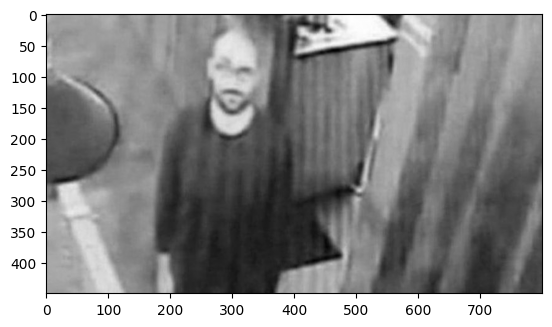

In [6]:
cctv = cv.imread("backup.jpg")
graycctv = cv.cvtColor(cctv, cv.COLOR_BGR2GRAY)
plt.imshow(graycctv, cmap="gray")

In [3]:
def filtering(img, size, mode):
    height, width = img.shape
    pad = size // 2

    # padding gambar
    padded = np.pad(img, pad, mode='edge')

    # canvas hasil
    canvas = np.zeros_like(img, dtype=np.uint8)

    match mode:

        # =========================
        # Mean Filter
        # =========================
        case 'mean':
            area = size * size

            for i in range(height):
                for j in range(width):

                    region = padded[i:i+size, j:j+size]

                    total = 0
                    for val in region.ravel():
                        total += int(val)

                    canvas[i, j] = total // area

        # =========================
        # Median Filter
        # =========================
        case 'median':

            for i in range(height):
                for j in range(width):

                    region = padded[i:i+size, j:j+size]

                    values = region.ravel().tolist()
                    values.sort()

                    n = len(values)
                    mid = n // 2

                    if n % 2 == 1:
                        median_val = values[mid]
                    else:
                        median_val = (values[mid - 1] + values[mid]) // 2

                    canvas[i, j] = median_val

        # =========================
        # Mode / Modus Filter
        # =========================
        case 'modus':

            for i in range(height):
                for j in range(width):

                    region = padded[i:i+size, j:j+size]

                    values = region.ravel()

                    count = {}

                    for val in values:
                        val = int(val)

                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1

                    max_count = 0
                    mode_val = 0

                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val

                    canvas[i, j] = mode_val

        # =========================
        # Sharpen Filter
        # =========================
        case 'sharp':

            kernel = np.array([
                [0, -1,  0],
                [-1, 5, -1],
                [0, -1,  0]
            ], dtype=np.float32)

            pad = 1
            padded = np.pad(img, pad, mode='edge')

            for i in range(height):
                for j in range(width):

                    region = padded[i:i+3, j:j+3]

                    val = np.sum(region.astype(np.float32) * kernel)

                    canvas[i, j] = np.clip(val, 0, 255)

        # =========================
        # Smooth Filter
        # =========================
        case 'smooth':

            kernel = np.ones((3, 3), dtype=np.float32) / 9

            pad = 1
            padded = np.pad(img, pad, mode='edge')

            for i in range(height):
                for j in range(width):

                    region = padded[i:i+3, j:j+3]

                    val = np.sum(region.astype(np.float32) * kernel)

                    canvas[i, j] = np.clip(val, 0, 255)

    return canvas

In [9]:
smoothccvt = filtering(graycctv, 3, 'smooth')
sharpccvt = filtering(graycctv, 3, 'sharp')
smoothsharpccvt = filtering(smoothccvt, 3, 'sharp')

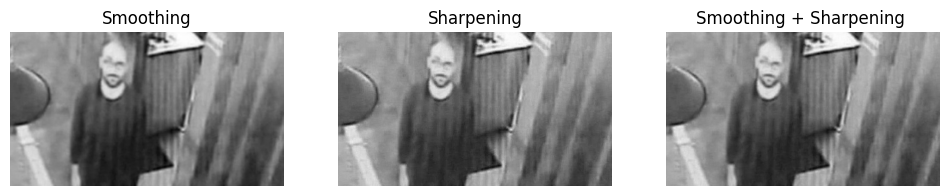

In [12]:
plt.figure(figsize=(12, 12))
plt.subplot(1, 3, 1)
plt.title("Smoothing")
plt.axis('off')
plt.imshow(smoothccvt, cmap="gray")

plt.subplot(1, 3, 2)
plt.title("Sharpening")
plt.axis('off')
plt.imshow(sharpccvt, cmap="gray")

plt.subplot(1, 3, 3)
plt.title("Smoothing + Sharpening ")
plt.axis('off')
plt.imshow(smoothsharpccvt, cmap="gray")

In [13]:
meanccvt = filtering(graycctv, 3, 'mean')
medianccvt = filtering(graycctv, 3, 'median')
modusccvt = filtering(graycctv, 3, 'modus')

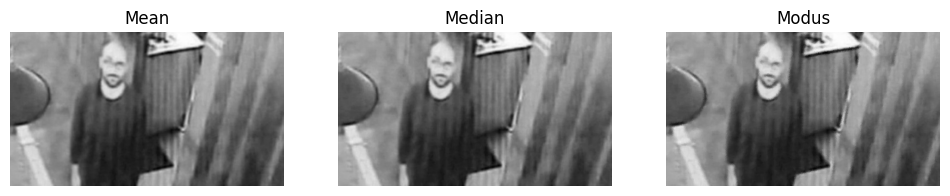

In [14]:
plt.figure(figsize=(12, 12))
plt.subplot(1, 3, 1)
plt.title("Mean")
plt.axis('off')
plt.imshow(meanccvt, cmap="gray")

plt.subplot(1, 3, 2)
plt.title("Median")
plt.axis('off')
plt.imshow(medianccvt, cmap="gray")

plt.subplot(1, 3, 3)
plt.title("Modus")
plt.axis('off')
plt.imshow(modusccvt, cmap="gray")

In [15]:
# ====================================
# Kernel Sobel
# ====================================

sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobelY = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)


# ====================================
# Kernel Prewitt
# ====================================

prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewittY = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
], dtype=np.float32)


# ====================================
# Kernel Roberts
# ====================================

robertsX = np.array([
    [1, 0],
    [0, -1]
], dtype=np.float32)

robertsY = np.array([
    [0, 1],
    [-1, 0]
], dtype=np.float32)


# ====================================
# Fungsi Convolution
# ====================================

def convolution(img, kernelX, kernelY=None):

    size = kernelX.shape[0]
    pad_size = size // 2

    height, width = img.shape

    padded = np.pad(img, pad_size, mode='edge')

    canvasX = np.zeros_like(img).astype(np.float32)

    # =========================
    # Convolution X
    # =========================

    for i in range(height):
        for j in range(width):

            region = padded[i:i+size, j:j+size]

            canvasX[i, j] = np.sum(region * kernelX)

    # =========================
    # Jika ada kernel Y
    # =========================

    if kernelY is not None:

        canvasY = np.zeros_like(img).astype(np.float32)

        for i in range(height):
            for j in range(width):

                region = padded[i:i+size, j:j+size]

                canvasY[i, j] = np.sum(region * kernelY)

        canvas = np.sqrt(canvasX**2 + canvasY**2)

    else:
        canvas = canvasX

    # =========================
    # Normalisasi
    # =========================

    canvas = canvas / canvas.max() * 255

    return np.clip(canvas, 0, 255).astype(np.uint8)

In [16]:
def convolutionlain(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    heigth, width = img.shape
    for i in range(heigth):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    return canvas

In [23]:
def edge (img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    canvas = np.zeros_like(img, dtype=np.float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)

In [54]:
def normalisasi(citra):
    min_val = int(citra[0,0])
    max_val = int(citra[0,0])
    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            if citra[i,j] < min_val: min_val = int(citra[i,j])
            if citra[i,j] > max_val: max_val = int(citra[i,j])
    
    hasil = np.zeros(citra.shape, dtype=np.uint8)
    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            hasil[i,j] = int((int(citra[i,j]) - min_val) / (max_val - min_val) * 255)
    return hasil

In [57]:
prewitt = edge(graycctv, prewittX, prewittY)
sobel = edge(graycctv, sobelX, sobelY)
roberts = edge(graycctv, robertsX, robertsY)
prewitSobel = edge(prewitt, sobelX, sobelY)
prewitRoberts = edge(prewitt, robertsX, robertsY)
sobelRoberts = edge(sobel, robertsX, robertsY)
prewitSobelRoberts = edge(prewitSobel, robertsX, robertsY)

In [58]:
norprewitt = normalisasi(prewitt)
norsobel = normalisasi(sobel)
norroberts = normalisasi(roberts)
norprewitSobel = normalisasi(prewitSobel)
norprewitRoberts = normalisasi(prewitRoberts)
norsobelRoberts = normalisasi(sobelRoberts)
norprewitSobelRoberts = normalisasi(prewitSobelRoberts)

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

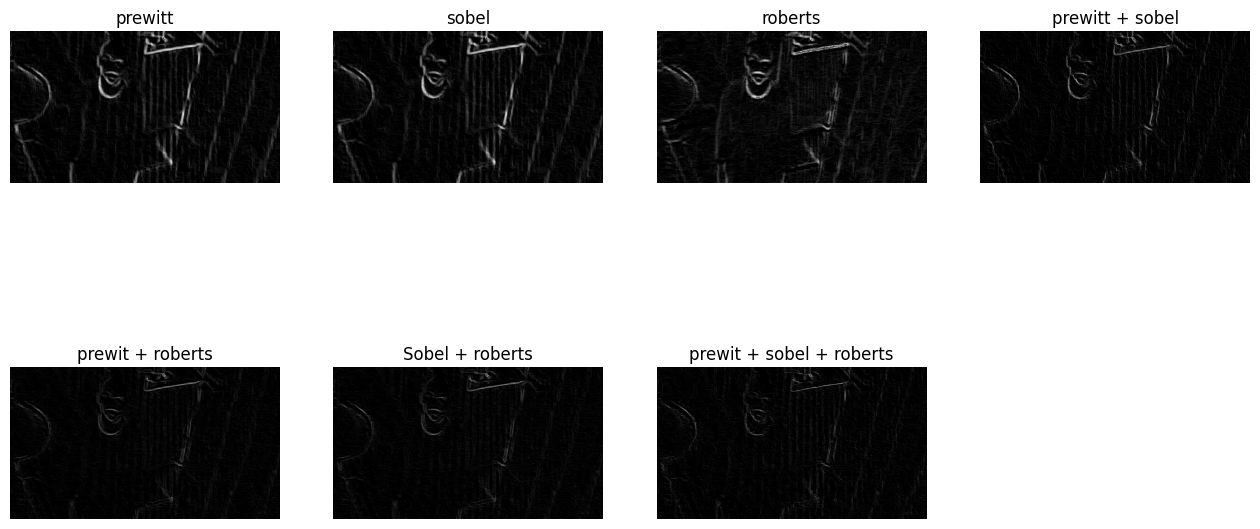

In [59]:
plt.figure(figsize=(16,8))
plt.subplot(2,4,1)
plt.imshow(norprewitt, cmap='gray')
plt.title('prewitt')
plt.axis('off')
plt.subplot(2,4,2)
plt.imshow(norsobel, cmap='gray')
plt.title('sobel')
plt.axis('off')
plt.subplot(2,4,3)
plt.imshow(norroberts, cmap='gray')
plt.title('roberts')
plt.axis('off')
plt.subplot(2,4,4)
plt.imshow(norprewitSobel, cmap='gray')
plt.title('prewitt + sobel')
plt.axis('off')
plt.subplot(2,4,5)
plt.imshow(norprewitRoberts, cmap='gray')
plt.title('prewit + roberts')
plt.axis('off')
plt.subplot(2,4,6)
plt.imshow(norsobelRoberts, cmap='gray')
plt.title('Sobel + roberts')
plt.axis('off')
plt.subplot(2,4,7)
plt.imshow(norprewitSobelRoberts, cmap='gray')
plt.title('prewit + sobel + roberts')
plt.axis('off')


In [60]:
def thresholding(image, angka):
    h, w = image.shape
    hasil = np.zeros((h,w), dtype=image.dtype)
    
    for x in range(h):
        for y in range(w):
            if(image[x,y] >= angka):
                hasil[x,y] = 255
            else:
                hasil[x,y] = 0
    return hasil

In [72]:
thresTepi10 = thresholding(prewitSobel, 10)
thresTepi20 = thresholding(prewitSobel, 20)
thresTepi30 = thresholding(prewitSobel, 30)
thresTepi40 = thresholding(prewitSobel, 40)
thresTepi50 = thresholding(prewitSobel, 50)
thresTepi60 = thresholding(prewitSobel, 60)

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

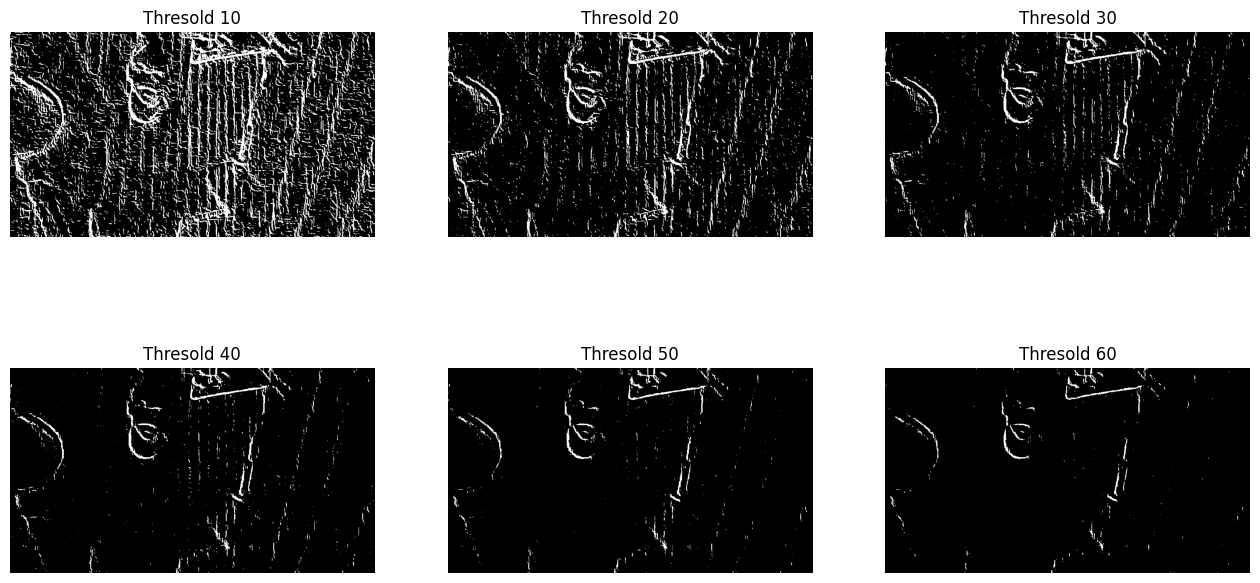

In [73]:
plt.figure(figsize=(16,8))
plt.subplot(2,3,1)
plt.imshow(thresTepi10, cmap='gray')
plt.title('Thresold 10')
plt.axis('off')
plt.subplot(2,3,2)
plt.imshow(thresTepi20, cmap='gray')
plt.title('Thresold 20')
plt.axis('off')
plt.subplot(2,3,3)
plt.imshow(thresTepi30, cmap='gray')
plt.title('Thresold 30')
plt.axis('off')
plt.subplot(2,3,4)
plt.imshow(thresTepi40, cmap='gray')
plt.title('Thresold 40')
plt.axis('off')
plt.subplot(2,3,5)
plt.imshow(thresTepi50, cmap='gray')
plt.title('Thresold 50')
plt.axis('off')
plt.subplot(2,3,6)
plt.imshow(thresTepi60, cmap='gray')
plt.title('Thresold 60')
plt.axis('off')

In [66]:
def reflect_padding(citra, pad):
    h, w = citra.shape[:2]
    if citra.ndim == 3:
        hasil = np.zeros((h + 2*pad, w + 2*pad, citra.shape[2]), dtype=citra.dtype)
    else:
        hasil = np.zeros((h + 2*pad, w + 2*pad), dtype=citra.dtype)
    
    # 1. Masukkan citra asli ke tengah
    hasil[pad:pad+h, pad:pad+w] = citra
    
    # 2. Pantulkan bagian atas dan bawah
    # Kita ambil area di dekat tepi, lalu balik urutannya dengan [::-1]
    hasil[:pad, pad:pad+w] = citra[1:pad+1, :][::-1]
    hasil[pad+h:, pad:pad+w] = citra[h-pad-1:h-1, :][::-1]
    
    # 3. Pantulkan bagian kiri dan kanan
    hasil[:, :pad] = hasil[:, pad+1:2*pad+1][:, ::-1]
    hasil[:, pad+w:] = hasil[:, pad+w-pad-1:pad+w-1][:, ::-1]
    
    return hasil

In [67]:
def spatial_masking(citra, kernel):
    """
    citra: Gambar grayscale
    kernel: Matriks masker (misal 3x3 atau 5x5)
    """
    h, w = citra.shape
    k_h, k_w = kernel.shape
    pad = k_h // 2
    
    # 1. Gunakan padding agar ukuran output tetap sama dengan input
    padded = reflect_padding(citra, pad) # Memanggil fungsi padding sebelumnya
    
    # 2. Siapkan array hasil
    hasil = np.zeros((h, w), dtype=np.float64)
    
    # 3. Proses Konvolusi (Sliding Window)
    for i in range(h):
        for j in range(w):
            # Ambil area lokal seukuran kernel
            region = padded[i : i + k_h, j : j + k_w]
            
            # Perkalian elemen-per-elemen dan jumlahkan (Dot Product)
            nilai_baru = np.sum(region * kernel)
            hasil[i, j] = nilai_baru
            
    # 4. Normalisasi agar tetap di rentang 0-255
    return np.clip(hasil, 0, 255).astype(np.uint8)

In [68]:
def binary_masking(citra, masker):
    """
    citra: Gambar asli
    masker: Gambar hitam putih berukuran sama dengan citra
    """
    h, w = citra.shape[:2]
    # Pastikan masker dalam format binary (0 atau 1)
    # Jika masker 0-255, kita ubah jadi 0 atau 1
    mask_bin = (masker > 127).astype(np.uint8)
    
    # Siapkan kanvas hasil
    if citra.ndim == 3:
        hasil = np.zeros_like(citra)
        for c in range(citra.shape[2]): # Loop untuk tiap kanal warna (R, G, B)
            hasil[:, :, c] = citra[:, :, c] * mask_bin
    else:
        hasil = citra * mask_bin
        
    return hasil.astype(np.uint8)

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

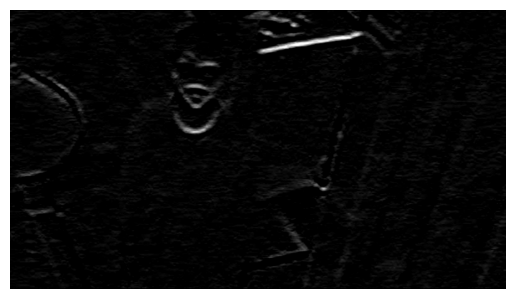

In [71]:
tes = spatial_masking(graycctv, sobelY)

plt.imshow(tes, cmap='gray')
plt.axis('off')

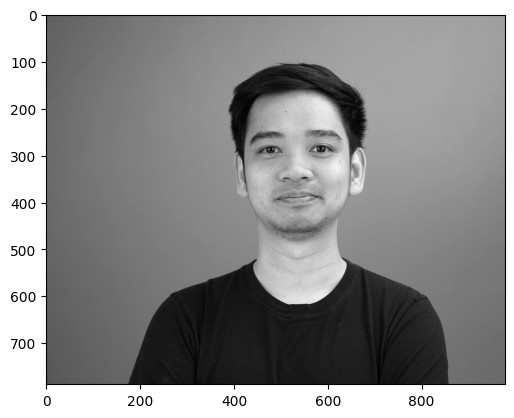

In [83]:
david = cv.imread("david.jpg")
davidgray = cv.cvtColor(david, cv.COLOR_BGR2GRAY)
plt.imshow(davidgray, cmap="gray")

(np.float64(-0.5), np.float64(977.5), np.float64(787.5), np.float64(-0.5))

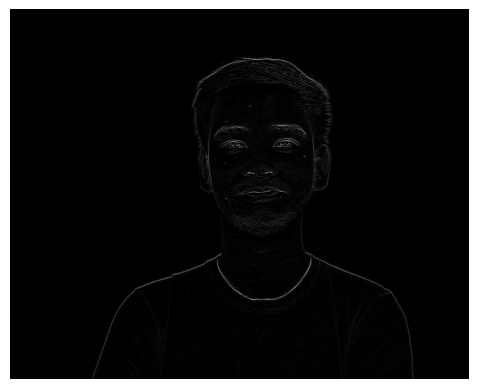

In [87]:
davidtepi = edge(davidgray, robertsX, robertsY)

plt.imshow(davidtepi, cmap='gray')
plt.axis('off')